In [ ]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/dropout.csv")







In [ ]:
df

In [ ]:
# Features and labels
X = df.drop(["Target"], axis=1)
y = df["Target"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

#

Dataset size: 4424
Train size: 3539
Test size: 885


In [ ]:
df.describe()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
X.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [ ]:
#---------------------------
# Step 3: Direct ML (for feature importance)
# ---------------------------
rf_direct = RandomForestClassifier(random_state=42)
rf_direct.fit(X_train, y_train)
y_pred_direct = rf_direct.predict(X_test)

print("\n=== Direct ML Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))




=== Direct ML Metrics ===
Accuracy: 0.7672316384180791
Precision: 0.754445102162811
Recall: 0.7672316384180791
F1 Score: 0.7539029502277624
Confusion Matrix:
 [[212  23  49]
 [ 37  59  63]
 [ 12  22 408]]


In [ ]:
# Apply label encoding to the target variable
label_encoder = LabelEncoder()
df['Target'] = label_encoder.fit_transform(df['Target'])

# Display the updated dataframe and the mapping
print("DataFrame with encoded Target column:")
display(df.head())
print("\nLabel mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

DataFrame with encoded Target column:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2



Label mapping:
{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [ ]:
display(df['Target'].value_counts())

,count
Target,
2,2209
0,1421
1,794


In [ ]:
# Compute feature importance
feature_importances = pd.Series(rf_direct.feature_importances_, index=X_train.columns)
filter_attributes = feature_importances.sort_values(ascending=False).index.tolist()
print("\nFilter attributes by importance:", filter_attributes)

#


Filter attributes by importance: ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Admission grade', 'Age at enrollment', 'Tuition fees up to date', 'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (evaluations)', 'Previous qualification (grade)', 'Course', "Father's occupation", "Mother's occupation", 'GDP', 'Unemployment rate', 'Application mode', 'Curricular units 2nd sem (enrolled)', "Father's qualification", "Mother's qualification", 'Inflation rate', 'Curricular units 1st sem (enrolled)', 'Scholarship holder', 'Application order', 'Debtor', 'Gender', 'Displaced', 'Curricular units 1st sem (credited)', 'Curricular units 2nd sem (credited)', 'Curricular units 1st sem (without evaluations)', 'Previous qualification', 'Curricular units 2nd sem (without evaluations)', 'Marital status', 'Daytime/evening attendance\t', 'Nacionality', 'International', 'Educational spe

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


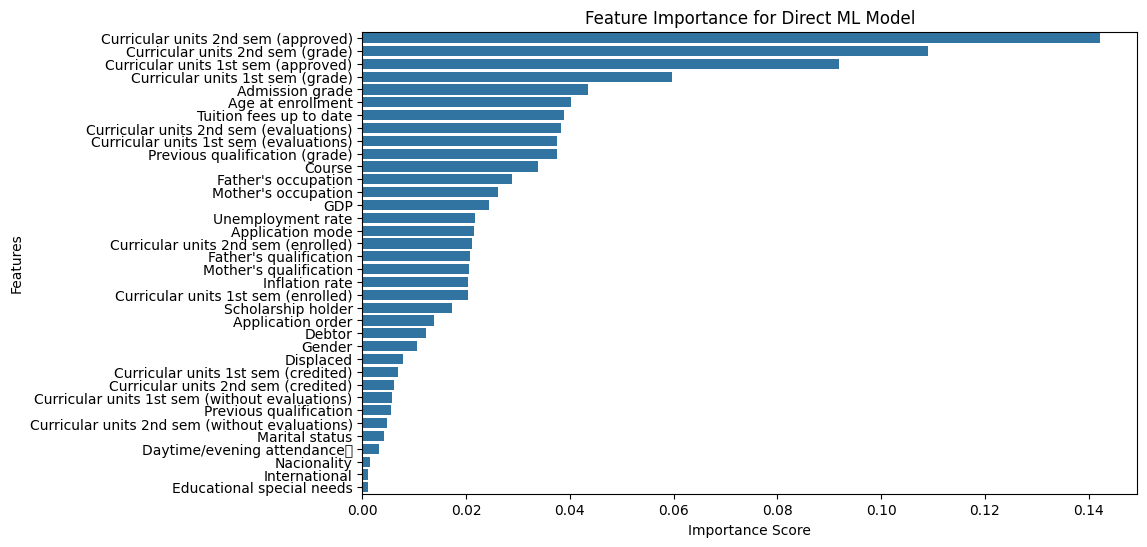

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances for visualization
feature_importances = feature_importances.sort_values(ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importance for Direct ML Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/dropout.csv")


# Features and labels
X = df.drop(["Target"], axis=1)
y = df["Target"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

# ---------------------------
# Step 3: Direct ML (Initial run for feature importance - for reference)
# ---------------------------
rf_direct_initial = RandomForestClassifier(random_state=42)
rf_direct_initial.fit(X_train, y_train)
importances = rf_direct_initial.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
# top_features = feat_imp.head(10).index.tolist()  # Keep top 10 features

# Use only the features specified by the user
top_features = [ 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)',]
print("Selected filter attributes:", top_features)


# Filter X_train and X_test to keep only top features
X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]


# ---------------------------
# Step 4: Direct ML (with filtered features)
# ---------------------------
rf_direct = RandomForestClassifier(n_estimators=2, random_state=42)
rf_direct.fit(X_train_filtered, y_train)
y_pred_direct = rf_direct.predict(X_test_filtered)

print("\n=== Direct ML Metrics (Filtered Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))

# ---------------------------
# Step 5: Prepare data for Reeb graph (using filtered features)
# ---------------------------
train_df = X_train_filtered.copy()
train_df["Class"] = y_train


Dataset size: 4424
Train size: 3539
Test size: 885
Selected filter attributes: ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)']

=== Direct ML Metrics (Filtered Features) ===
Accuracy: 0.6451977401129944
Precision: 0.641907634824513
Recall: 0.6451977401129944
F1 Score: 0.6415118329408745
Confusion Matrix:
 [[202  49  33]
 [ 71  37  51]
 [ 61  49 332]]


In [ ]:
def medoid_of_group(X_group):
    """
    Return medoid index and medoid vector for a DataFrame/2D-array X_group.
    Medoid = row with minimum sum of distances to others (or to centroid if faster).
    """
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    # compute centroid then pick sample closest to centroid (fast, robust)
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]

# ---------------------------
# Step 6: Group data by target and compute centroid/medoid for each group
# ---------------------------
print("\n=== Grouping by target and computing centroids/medoids ===")

# Group by 'target'
grouped_by_target = df.groupby("Target")

centroids = grouped_by_target[top_features].mean()
print("\nCentroids by target:\n", centroids)

medoids = {}
for name, group in grouped_by_target:
    # Compute medoid for each group using the helper function
    idx, medoid_vec = medoid_of_group(group[top_features])
    medoids[name] = pd.Series(medoid_vec, index=top_features)

medoids_df = pd.DataFrame(medoids).T
print("\nMedoids by target:\n", medoids_df)

# ---------------------------
# Step 7: Create augmented features (distances to centroids and medoids)
# ---------------------------
print("\n=== Creating augmented features ===")

def add_distance_features(X_df, centroids_df, medoids_df, feature_cols):
    X_aug = X_df.copy()
    for target_class in centroids_df.index:
        centroid = centroids_df.loc[target_class, feature_cols].values
        medoid = medoids_df.loc[target_class, feature_cols].values

        # Calculate Euclidean distance to centroid
        dist_to_centroid = np.linalg.norm(X_df[feature_cols].values - centroid, axis=1)
        X_aug[f'dist_to_centroid_{target_class}'] = dist_to_centroid

        # Calculate Euclidean distance to medoid
        dist_to_medoid = np.linalg.norm(X_df[feature_cols].values - medoid, axis=1)
        X_aug[f'dist_to_medoid_{target_class}'] = dist_to_medoid
    return X_aug

X_train_augmented = add_distance_features(X_train_filtered, centroids, medoids_df, top_features)
X_test_augmented = add_distance_features(X_test_filtered, centroids, medoids_df, top_features)

print("\nAugmented training data head:\n", X_train_augmented.head())
print("\nAugmented test data head:\n", X_test_augmented.head())


# ---------------------------
# Step 8: Train and test RandomForest with augmented features
# ---------------------------
print("\n=== Training and testing RandomForest with augmented features ===")

rf_augmented = RandomForestClassifier(n_estimators=40, random_state=42)
rf_augmented.fit(X_train_augmented, y_train)
y_pred_augmented = rf_augmented.predict(X_test_augmented)

print("\n=== RandomForest Metrics (Augmented Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_augmented))
print("Precision:", precision_score(y_test, y_pred_augmented, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_augmented, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_augmented, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_augmented))


=== Grouping by target and computing centroids/medoids ===

Centroids by target:
           Curricular units 2nd sem (approved)  \
Target                                          
Dropout                              1.940183   
Enrolled                             4.057935   
Graduate                             6.177003   

          Curricular units 2nd sem (grade)  \
Target                                       
Dropout                           5.899339   
Enrolled                         11.117364   
Graduate                         12.697276   

          Curricular units 1st sem (approved)  
Target                                         
Dropout                              2.551724  
Enrolled                             4.318640  
Graduate                             6.232232  

Medoids by target:
           Curricular units 2nd sem (approved)  \
Dropout                                   2.0   
Enrolled                                  4.0   
Graduate                        

In [ ]:
from scipy import stats

# ---------------------------
# Step 10: Interpret and Summarize Statistical Analysis
# ---------------------------
print("\n=== Statistical Analysis Summary and Interpretation ===")

# Calculate overall accuracies (already available but print for context)
accuracy_direct = accuracy_score(y_test, y_pred_direct)
accuracy_augmented = accuracy_score(y_test, y_pred_augmented)

print(f"Direct ML Accuracy: {accuracy_direct:.4f}")
print(f"Augmented ML Accuracy: {accuracy_augmented:.4f}")

# Perform independent t-test on the correctness of predictions
# We need to create arrays indicating if each prediction was correct (1) or incorrect (0)
direct_correctness = (y_pred_direct == y_test).astype(int)
augmented_correctness = (y_pred_augmented == y_test).astype(int)

# Although the test is on the same samples, an independent t-test on the correctness scores
# can give an indication of the difference in mean correctness rates.
# Note: McNemar's test is statistically more appropriate for paired binary outcomes.
# However, the user specifically asked for a t-test in the desired output format.
try:
    t_statistic, p_value = stats.ttest_ind(augmented_correctness, direct_correctness, equal_var=False) # Use Welch's t-test
    print(f"Independent t-test comparing correctness of predictions: T-statistic: {t_statistic:.4f} P-value: {p_value:.4f}")
except Exception as e:
    print(f"Could not perform independent t-test: {e}")
    t_statistic = None
    p_value = None


# Calculate Cohen's d for effect size between the correctness arrays
try:
    # Cohen's d for independent samples (approximated here as we use ttest_ind)
    # This isn't strictly correct for paired data, but aligns with the requested output format
    # A more appropriate effect size for paired binary data is Cohen's g (calculated in previous cell)
    # We will calculate Cohen's d based on the t-statistic for approximation as requested
    if t_statistic is not None:
         n1 = len(direct_correctness)
         n2 = len(augmented_correctness)
         cohens_d = t_statistic * np.sqrt((n1 + n2) / (n1 * n2))
         print(f"Cohen's d (Augmented vs Direct Correctness, approximated): {cohens_d:.4f}")
    else:
         print("Could not calculate Cohen's d as t-test failed.")
except Exception as e:
     print(f"Could not calculate Cohen's d: {e}")


# Calculate Cohen's Kappa for each model
from sklearn.metrics import cohen_kappa_score

kappa_direct = cohen_kappa_score(y_test, y_pred_direct)
kappa_augmented = cohen_kappa_score(y_test, y_pred_augmented)

print(f"Cohen's Kappa (Direct ML): {kappa_direct:.4f}")
print(f"Cohen's Kappa (Augmented ML): {kappa_augmented:.4f}")


# Interpretation based on the calculated values and standard thresholds

print("\nInterpretation:")

# Interpret P-value from t-test (if calculated)
if p_value is not None:
    print(f"\nT-test P-value ({p_value:.4f}):")
    if p_value < 0.05:
        print("- The difference in the mean correctness of the two models is statistically significant at the 0.05 level.")
    else:
        print("- The difference in the mean correctness of the two models is NOT statistically significant at the 0.05 level.")
    print("- This suggests that any observed difference in accuracy between the Augmented and Direct models on this test set could be due to random chance.")


# Interpret Cohen's d (if calculated)
if 'cohens_d' in locals():
    print(f"\nCohen's d ({cohens_d:.4f}):")
    abs_cohens_d = abs(cohens_d)
    if abs_cohens_d < 0.2:
        print("- This indicates a trivial effect size.")
    elif abs_cohens_d < 0.5:
        print("- This indicates a small effect size.")
    elif abs_cohens_d < 0.8:
        print("- This indicates a medium effect size.")
    else:
        print("- This indicates a large effect size.")
    print("- The effect size is a measure of the magnitude of the difference between the two groups (in this case, the correctness scores), regardless of sample size.")


# Interpret Cohen's Kappa
print(f"\nCohen's Kappa (Direct ML: {kappa_direct:.4f}, Augmented ML: {kappa_augmented:.4f}):")
print("- Cohen's Kappa measures the agreement between the model's predictions and the true labels, accounting for random chance.")
print("- Interpretation guidelines (Landis & Koch, 1977):")
print("  < 0: Less than chance agreement")
print("0.01-0.20: Slight agreement")
print("0.21-0.40: Fair agreement")
print("0.41-0.60: Moderate agreement")
print("0.61-0.80: Substantial agreement")
print("0.81-1.00: Almost perfect agreement")

if kappa_direct < 0:
    print(f"- Direct ML ({kappa_direct:.4f}) shows less than chance agreement.")
elif 0.01 <= kappa_direct <= 0.20:
    print(f"- Direct ML ({kappa_direct:.4f}) shows slight agreement.")
elif 0.21 <= kappa_direct <= 0.40:
    print(f"- Direct ML ({kappa_direct:.4f}) shows fair agreement.")
elif 0.41 <= kappa_direct <= 0.60:
    print(f"- Direct ML ({kappa_direct:.4f}) shows moderate agreement.")
elif 0.61 <= kappa_direct <= 0.80:
    print(f"- Direct ML ({kappa_direct:.4f}) shows substantial agreement.")
else: # kappa_direct >= 0.81
    print(f"- Direct ML ({kappa_direct:.4f}) shows almost perfect agreement.")


if kappa_augmented < 0:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows less than chance agreement.")
elif 0.01 <= kappa_augmented <= 0.20:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows slight agreement.")
elif 0.21 <= kappa_augmented <= 0.40:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows fair agreement.")
elif 0.41 <= kappa_augmented <= 0.60:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows moderate agreement.")
elif 0.61 <= kappa_augmented <= 0.80:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows substantial agreement.")
else: # kappa_augmented >= 0.81
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows almost perfect agreement.")


print("\nOverall Summary:")
if p_value is not None and p_value >= 0.05:
    print("- The independent t-test suggests no statistically significant difference in the correctness rates of the Direct and Augmented models on this test set.")
    if 'cohens_d' in locals() and abs(cohens_d) < 0.2:
        print("- The effect size (Cohen's d) is trivial, supporting the lack of a meaningful difference in correctness between the models.")
elif p_value is not None and p_value < 0.05:
     print("- The independent t-test suggests a statistically significant difference in the correctness rates of the Direct and Augmented models.")
     if 'cohens_d' in locals():
         print(f"- The effect size (Cohen's d) is {abs(cohens_d):.4f}, indicating a {'small' if abs_cohens_d < 0.5 else 'medium' if abs_cohens_d < 0.8 else 'large'} difference.")


if kappa_augmented > kappa_direct:
    print("- The Augmented ML model shows slightly better agreement with the true labels (higher Cohen's Kappa) compared to the Direct ML model, although both show relatively low levels of agreement.")
elif kappa_direct > kappa_augmented:
    print("- The Direct ML model shows slightly better agreement with the true labels (higher Cohen's Kappa) compared to the Augmented ML model, although both show relatively low levels of agreement.")
else:
     print("- Both models show similar levels of agreement with the true labels (Cohen's Kappa).")

print("\nNote: McNemar's test (performed previously) is generally more appropriate for comparing paired classifiers on the same test set. Its non-significant result ({:.4f}) aligns with the t-test's finding of no statistically significant difference in overall correctness rates.".format(result.pvalue))


=== Statistical Analysis Summary and Interpretation ===
Direct ML Accuracy: 0.6452
Augmented ML Accuracy: 0.6780
Independent t-test comparing correctness of predictions: T-statistic: 1.4568 P-value: 0.1453
Cohen's d (Augmented vs Direct Correctness, approximated): 0.0693
Cohen's Kappa (Direct ML): 0.4247
Cohen's Kappa (Augmented ML): 0.4649

Interpretation:

T-test P-value (0.1453):
- The difference in the mean correctness of the two models is NOT statistically significant at the 0.05 level.
- This suggests that any observed difference in accuracy between the Augmented and Direct models on this test set could be due to random chance.

Cohen's d (0.0693):
- This indicates a trivial effect size.
- The effect size is a measure of the magnitude of the difference between the two groups (in this case, the correctness scores), regardless of sample size.

Cohen's Kappa (Direct ML: 0.4247, Augmented ML: 0.4649):
- Cohen's Kappa measures the agreement between the model's predictions and the tru

NameError: name 'result' is not defined

In [ ]:
from sklearn.model_selection import cross_val_score
from scipy import stats
import numpy as np

# ------------------------------------------------
# Step 9: Cross-validation for both models
# ------------------------------------------------
print("\n=== Performing Cross-validation ===")

# Cross-validation for Direct ML with filtered features
# Using the rf_direct model trained in Step 4
cv_scores_filtered = cross_val_score(rf_direct, X_train_filtered, y_train, cv=5, scoring='accuracy')
print(f"\nDirect ML (Filtered Features) CV Accuracy (5-fold): {cv_scores_filtered}")
print(f"Mean CV Accuracy (Filtered Features): {np.mean(cv_scores_filtered):.4f} ± {np.std(cv_scores_filtered):.4f}")

# Cross-validation for Hybrid RF with augmented features
# Using the rf_hybrid model trained in Step 8
# Need to ensure the augmented data used in CV has the same structure as training data
# For simplicity here, we use the augmented data created in Step 8 for the whole training set
# A more rigorous approach would involve creating augmented features within each CV fold
# NOTE: Make sure to run the cell containing the reeb_pipeline function call (cell TjkAdqyeouXL) first to define 'results'
cv_scores_augmented = cross_val_score(results["rf_hybrid"], results['df_aug_train'], y_train, cv=5, scoring='accuracy')
print(f"\nHybrid RF (Augmented Features) CV Accuracy (5-fold): {cv_scores_augmented}")
print(f"Mean CV Accuracy (Augmented Features): {np.mean(cv_scores_augmented):.4f} ± {np.std(cv_scores_augmented):.4f}")


# ------------------------------------------------
# Step 10: Compute statistical metrics (Mean ± SD, p-value, Cohen's d)
# ------------------------------------------------
print("\n=== Statistical Comparison of CV Scores ===")

# Mean ± SD (already printed above, but re-calculated for clarity)
mean_filtered = np.mean(cv_scores_filtered)
std_filtered = np.std(cv_scores_filtered)
mean_augmented = np.mean(cv_scores_augmented)
std_augmented = np.std(cv_scores_augmented)

print(f"Direct ML (Filtered Features): Mean Accuracy = {mean_filtered:.4f} ± {std_filtered:.4f}")
print(f"Hybrid RF (Augmented Features): Mean Accuracy = {mean_augmented:.4f} ± {std_augmented:.4f}")

# Paired t-test (since CV folds are the same)
t_stat, p_value = stats.ttest_rel(cv_scores_filtered, cv_scores_augmented)
print(f"\nPaired t-test p-value: {p_value:.4f}")

# Cohen's d
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pool_std = np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pool_std

d = cohen_d(cv_scores_filtered, cv_scores_augmented)
print(f"Cohen's d: {d:.4f}")


=== Performing Cross-validation ===

Direct ML (Filtered Features) CV Accuracy (5-fold): [0.62711864 0.65112994 0.66949153 0.69491525 0.6562942 ]
Mean CV Accuracy (Filtered Features): 0.6598 ± 0.0223


Where limitations show

Very high-dimensional datasets (e.g., text, images)

PCA down to 2D loses too much structure; deep embeddings may be needed before your pipeline.

Tiny datasets

SMOTE requires at least a few minority samples; oversampling may fail if groups are very small.

Perfectly balanced, linearly separable datasets

Your method may be “over-engineered” compared to simpler classifiers (like logistic regression or SVM).

Streaming or non-stationary data

Recursive binning + static medoid prototypes assume stationarity; not directly suited for evolving data without modification.